In [ ]:
from google.colab import files
uploaded = files.upload()

Saving test.csv.zip to test.csv.zip


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving train.csv.zip to train.csv.zip


In [ ]:
df = pd.read_csv('train.csv.zip')   # change name if different
df.head()

/tmp/ipykernel_10647/1139100317.py:1: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('train.csv.zip')   # change name if different


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

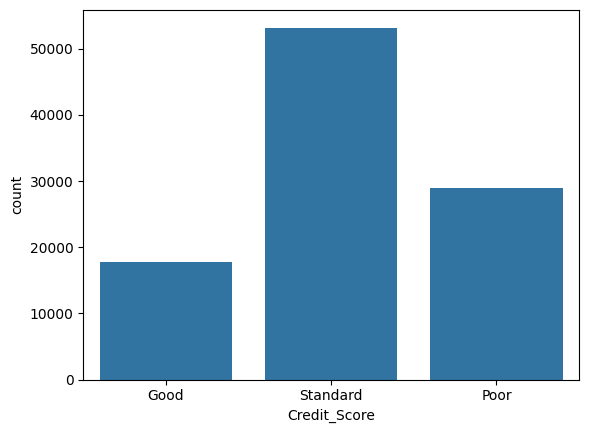

In [ ]:
print(df.info())
print(df.describe())

# Check nulls
print(df.isnull().sum())

# Target distribution
sns.countplot(x='Credit_Score', data=df)
plt.show()

In [ ]:
# Drop irrelevant columns
df = df.drop(['ID', 'Customer_ID', 'Name', 'SSN'], axis=1, errors='ignore')

# Replace '_' or invalid strings with NaN
df = df.replace('_', np.nan)

# Convert numeric columns properly
for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except:
        pass

# Handle missing values
df = df.ffill()   # instead of fillna(method='ffill')

# Encode categorical columns safely
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str)   # 🔥 important fix
    df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop('Credit_Score', axis=1)
y = df['Credit_Score']

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
pca = PCA(n_components=0.95)  # keep 95% variance
X_pca = pca.fit_transform(X_scaled)

print("Reduced dimensions:", X_pca.shape)

Reduced dimensions: (100000, 21)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier()
}

from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))


Decision Tree
Accuracy: 0.54385
              precision    recall  f1-score   support

           0       0.40      0.41      0.40      3527
           1       0.50      0.49      0.49      5874
           2       0.62      0.62      0.62     10599

    accuracy                           0.54     20000
   macro avg       0.51      0.51      0.51     20000
weighted avg       0.54      0.54      0.54     20000


Random Forest
Accuracy: 0.645
              precision    recall  f1-score   support

           0       0.52      0.43      0.47      3527
           1       0.71      0.50      0.59      5874
           2       0.65      0.80      0.72     10599

    accuracy                           0.65     20000
   macro avg       0.63      0.58      0.59     20000
weighted avg       0.65      0.65      0.64     20000


KNN
Accuracy: 0.6003
              precision    recall  f1-score   support

           0       0.45      0.52      0.48      3527
           1       0.60      0.55      0.57

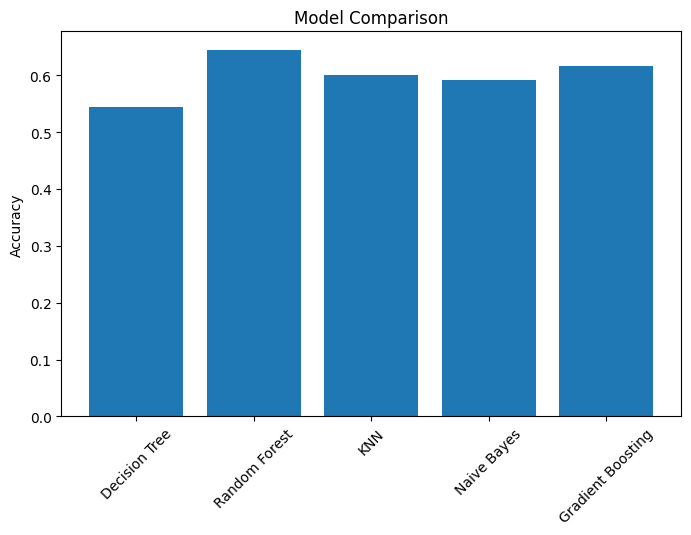

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values())
plt.xticks(rotation=45)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

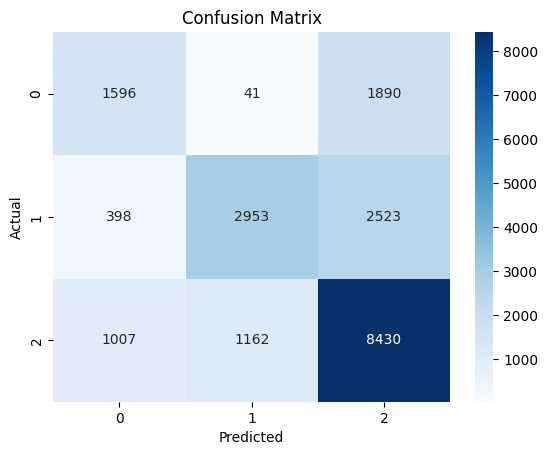

In [ ]:
best_model = RandomForestClassifier()
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

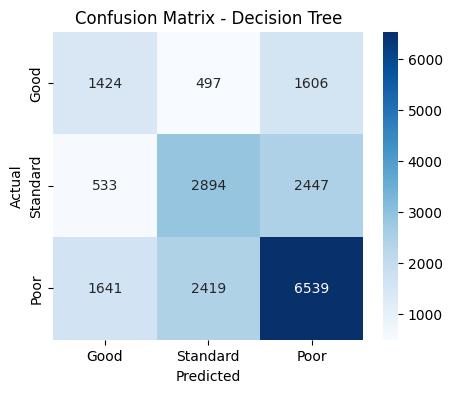

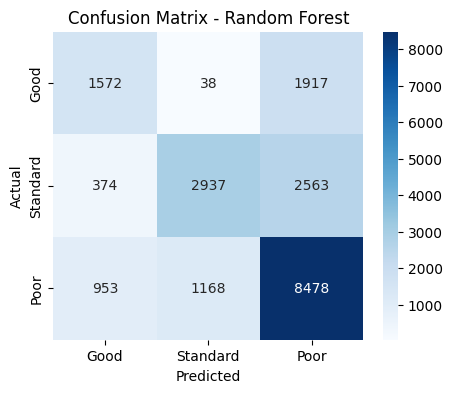

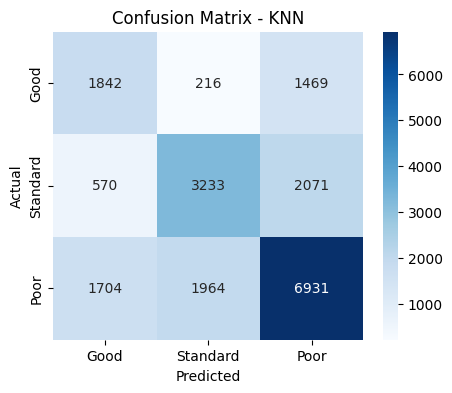

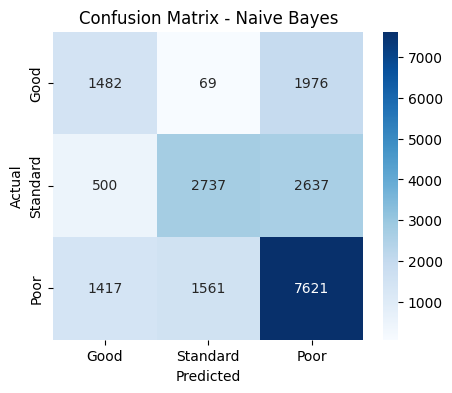

KeyboardInterrupt: 

In [ ]:
labels = ['Good', 'Standard', 'Poor']

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)

    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

In [ ]:
# Replace garbage values
df = df.replace('_', np.nan)

# Clean numeric columns
for col in df.columns:
    df[col] = df[col].astype(str).str.replace('[^0-9.-]', '', regex=True)
    df[col] = pd.to_numeric(df[col], errors='ignore')

# Fill missing values
df = df.fillna(df.median(numeric_only=True))

# One-hot encoding (better than LabelEncoder)
df = pd.get_dummies(df, drop_first=True)

/tmp/ipykernel_10647/979608123.py:7: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')
/tmp/ipykernel_10647/979608123.py:7: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')
/tmp/ipykernel_10647/979608123.py:7: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')
/tmp/ipykernel_10647/979608123.py:7: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


In [ ]:
X = df.drop('Credit_Score', axis=1)
y = df['Credit_Score']

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.769
              precision    recall  f1-score   support

           0       0.61      0.82      0.70      3527
           1       0.77      0.81      0.79      5874
           2       0.85      0.73      0.79     10599

    accuracy                           0.77     20000
   macro avg       0.74      0.79      0.76     20000
weighted avg       0.79      0.77      0.77     20000

